# １章３節８項 ドップラージオメトリ

## 概要
衛星が移動することで発生するドップラーの歪みを可視化します。


## 使用データ


| 項目 | 使用データなし |
| ---- | ---- |

In [ ]:
import os
import numpy as np
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm

PATH_OUTPUT = os.path.join('output', '1_3_8')
os.makedirs(PATH_OUTPUT, exist_ok=True)

<Figure size 3840x1920 with 0 Axes>

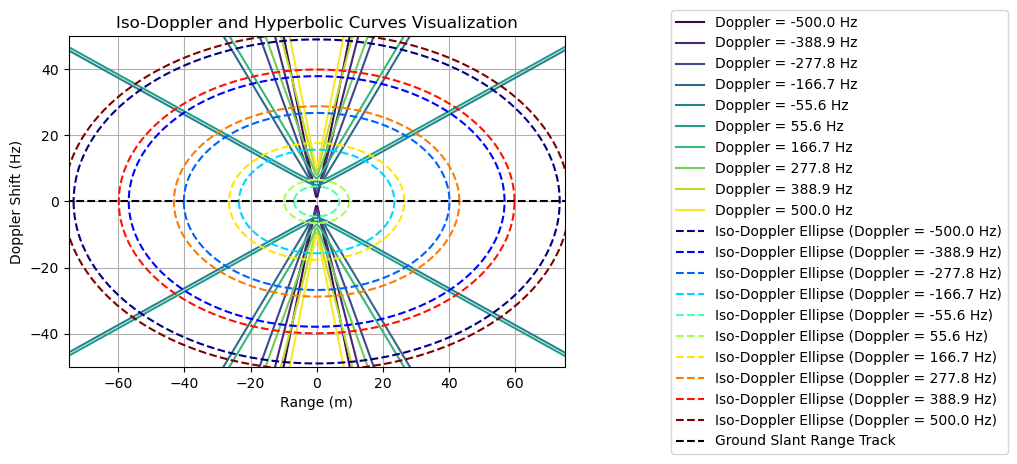

In [ ]:
# パラメータ
satellite_position = np.linspace(-100, 100, 500)  # 衛星がx軸上で直線運動するモデル
doppler_shifts = np.linspace(-500, 500, 10)     # Dopplerシフト範囲

# 楕円の形状パラメータ
a = 1.5  # 長軸
b = 1.0  # 短軸

# プロット設定
plt.figure(figsize=(24, 12), dpi=160, facecolor='w', edgecolor='k')
fig, ax = plt.subplots()
colors = plt.cm.viridis(np.linspace(0, 1, len(doppler_shifts)))
colors_jet = plt.cm.jet(np.linspace(0, 1, len(doppler_shifts)))

# 双曲線の形を持つiso-Doppler線のプロット
for i, doppler in enumerate(doppler_shifts):
    y_hyperbola = np.sqrt(1 + (satellite_position * doppler * 0.01) ** 2)  # Dopplerシフトに基づく双曲線
    ax.plot(satellite_position, y_hyperbola + i, label=f'Doppler = {doppler:.1f} Hz', color=colors[i])  # 上側の双曲線
    ax.plot(satellite_position, -y_hyperbola - i, color=colors[i])  # 下側の双曲線

# 楕円のiso-Doppler線（参照として、衛星が最接近点にいる場合のシナリオ）
theta = np.linspace(0, 2 * np.pi, 500)
for i, doppler in enumerate(doppler_shifts):
    r = 1 + doppler * 0.1  # Dopplerシフトに基づく半径の変化
    x_ellipse = a * r * np.cos(theta)  # 楕円のx座標
    y_ellipse = b * r * np.sin(theta)  # 楕円のy座標
    ax.plot(x_ellipse, y_ellipse, label=f'Iso-Doppler Ellipse (Doppler = {doppler:.1f} Hz)', linestyle='--', color=colors_jet[i])

# 衛星の軌道
ax.plot(satellite_position, np.zeros_like(satellite_position), '--', color='black' , label='Ground Slant Range Track')
ax.set_aspect('equal', 'box')  # アスペクト比を正確にして形を整える
ax.set_xlabel('Range (m)')
ax.set_ylabel('Doppler Shift (Hz)')
ax.set_title('Iso-Doppler and Hyperbolic Curves Visualization')
ax.set_ylim(-50, 50)  # Limit y-axis for better visibility
ax.set_xlim(-75, 75)  # Limit x-axis for better visibility
ax.legend(loc='upper left', bbox_to_anchor=(1.2, 1.1))  # 凡例をプロット外に移動
plt.grid(True)
plt.savefig(os.path.join(PATH_OUTPUT, 'iso-doppler_visualize.png'), 
            # transparent=True
            )
plt.show();plt.clf();plt.close();